In [ ]:
#1. Step 1 - Import Libraries
#2. Step 2 - Read dataset
#3. Filling missing values
#4. Descriptio of the dataset



In [1]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

In [3]:
df = pd.read_csv("/Users/mohanrajsubramaniam/PycharmProjects/python_learning/Pandas/datafiles/userData.csv")
df.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Purpose
0,35,Male,Skilled,Own,Moderate,Little,3500,Car
1,42,Female,Highly Skilled,Rent,Rich,Moderate,12000,Business
2,29,Male,Unskilled & Non-resident,Free,Little,Little,1800,Education
3,51,Female,Skilled,Own,Quite Rich,Rich,8500,Furniture/Equipment
4,38,Male,Highly Skilled,Rent,Moderate,Moderate,6200,Radio/TV


In [ ]:
# filling missing values
# Loop through entire dataframe and identify the missing values and replace with fillna() function and replace
# numberical values with mean and categorical values with mode.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Age               10 non-null     int64 
 1   Sex               10 non-null     object
 2   Job               10 non-null     object
 3   Housing           10 non-null     object
 4   Saving accounts   10 non-null     object
 5   Checking account  10 non-null     object
 6   Credit amount     10 non-null     int64 
 7   Purpose           10 non-null     object
dtypes: int64(2), object(6)
memory usage: 772.0+ bytes


In [15]:
# Filling  missing values
for column in df.columns:
    if df[column].dtype == 'object':
        print("Column " , column , "is categorical value")
        df[column].fillna(df[column].mode()[0], inplace=True)
    else:
        print("Column " , column , "is numerical value")
        df[column].fillna(df[column].mean(), inplace=True)

Column  Age is numerical value
Column  Sex is categorical value
Column  Job is categorical value
Column  Housing is categorical value
Column  Saving accounts is categorical value
Column  Checking account is categorical value
Column  Credit amount is numerical value
Column  Purpose is categorical value


/var/folders/1x/v6x4g9pj3zq4dnxfhmthd5hm0000gn/T/ipykernel_82458/623080505.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[column].fillna(df[column].mean(), inplace=True)
/var/folders/1x/v6x4g9pj3zq4dnxfhmthd5hm0000gn/T/ipykernel_82458/623080505.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values alwa

In [19]:
# use group by and transform to fill missing values in the 'Credit amount' column using the mean value of the grouped 'purpose' column.
#df['Credit Amount'] = df['Credit Amount'].fillna(df.groupby('Purpose')['Credit amount'].transsform('mean'))

#df['Credit amount'] = df['Credit amount'].fillna(
#    df.groupby('Purpose')['Credit amount'].transform('mean')
#)

# Filling  missing values
# User groupby() and transform to fill msising values to fill missing values
#in the credit amount column using mean value of the group by 'Purpose column

# Given column name = Credit amount
# replace with Credit amount (mean) by grouping by Purpose
df['Credit amount'] = df['Credit amount'].fillna(
    #group by Purpose
    #transfform mean
    df.groupby('Purpose')['Credit amount'].transform('mean')
)

In [20]:
# Filling  missing values
# User groupby() and transform to fill msising values to fill missing values
#in the credit amount column using mean value of the group by 'Purpose column

# Given column name = Credit amount
# replace with Credit amount (median) by grouping by Purpose
df['Credit amount'] = df['Credit amount'].fillna(
    #group by Purpose
    #transfform mean
    df.groupby('Purpose')['Credit amount'].transform('median')
)

In [31]:
# identify and remove columns with a high percentage of null
# values specifically those exceeding 25%

# identify the columns those are  exceeding 25 % null values

df.head()
missing_data_in_percentage = df.isnull().mean();
print(missing_data_in_percentage)
columns_to_drop = missing_data_in_percentage[missing_data_in_percentage>.25].index.to_list()
print('Columns to drop',columns_to_drop)
df = df.drop(columns=columns_to_drop)

Age                 0.0
Sex                 0.0
Job                 0.0
Housing             0.0
Saving accounts     0.0
Checking account    0.0
Credit amount       0.0
Purpose             0.0
dtype: float64
Columns to drop []


In [34]:
# 50 percentag drop

df.head()
missing_data_in_percentage = df.isnull().mean();

print(missing_data_in_percentage)
columns_to_drop = missing_data_in_percentage[missing_data_in_percentage>.5].index.to_list()
print('Columns to drop',columns_to_drop)
df = df.drop(columns=columns_to_drop)


Age                 0
Sex                 0
Job                 0
Housing             0
Saving accounts     0
Checking account    0
Credit amount       0
Purpose             0
dtype: int64


In [35]:
# Find the number of missing values in each columns and store in missing_counts  variables
df.head()
missing_counts = df.isnull().sum();
print(missing_counts)

Age                 0
Sex                 0
Job                 0
Housing             0
Saving accounts     0
Checking account    0
Credit amount       0
Purpose             0
dtype: int64


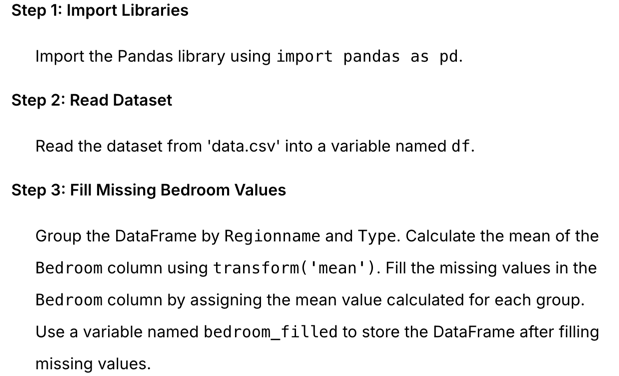

In [ ]:
# Step 3: Fill missing Bedroom values using group-wise mean
df['Bedroom'] = df['Bedroom'].fillna(
    df.groupby(['Regionname', 'Type'])['Bedroom'].transform('mean')
)

# Step 4: Store the result in a new variable
bedroom_filled = df.copy()

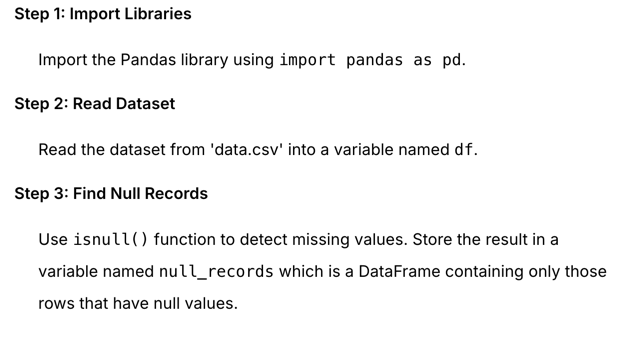
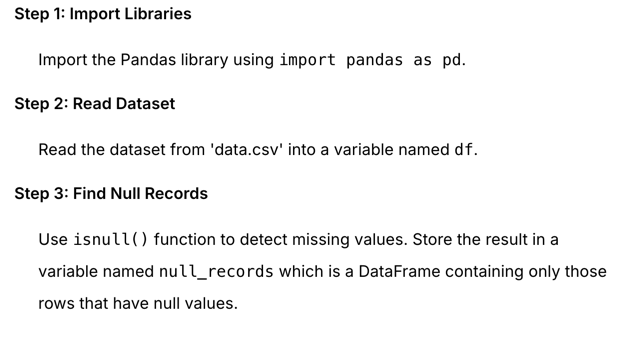

In [36]:
# Step 3: Find rows with any null values
null_records = df[df.isnull().any(axis=1)]

# Optional: display the result
print(null_records)

Empty DataFrame
Columns: [Age, Sex, Job, Housing, Saving accounts, Checking account, Credit amount, Purpose]
Index: []
